# 36: real stochastic series

The router of `dtfit.stochastic.fit_stochastic` was built and tuned on
synthetic processes (notebook 23). This notebook turns it on seven real
records nobody generated and checks whether what it detects matches what
the literature already says about each one, whether the forecast it
produces beats a random walk, and where the router still gets fooled.

Claims:

1. The detected regime matches the literature's own characterization on
   all seven series: GDP and both FX levels and the T-bill as random
   walks, CO2 as trend plus a seasonal cycle, sunspots as a cycle inside
   its known 8 to 14 year band, and the Nile as trend, not trend plus
   cycle. False if any of those does not match.
2. Held-out forecast skill never trails the random walk by more than 5
   percent on any of the seven series, and beats it by at least half on
   CO2 and GDP, the two series with the clearest deterministic structure.
   False if any ratio exceeds 1.05, or if CO2 or GDP is not below 0.5.
3. On USD/UAH the level is a random walk the merged model ties rather
   than beats, while the long memory the literature attributes to FX
   volatility shows up in the absolute log-returns and agrees across
   both of dtfit's image routes and the two classical estimators. False
   if the level forecast beats or trails the random walk by more than 2
   percent, or if the four Hurst estimates disagree by more than 0.1 or
   any falls at or below 0.55.
4. The Nile's 19.7-year "cycle" is an artifact of fitting a line through
   the 1899 Aswan Low Dam level shift, not a real periodicity, and the
   significance test on the cycle's spectral strength, stacked on the
   effect-size floor, is what closes the gate on it: with the test
   switched off the router reads trend plus cycle.
   False if a step model does not beat the pooled line by a wide AIC
   margin at equal parameter count, or if the cycle still clears the
   significance threshold.
5. The memory that is real in the Nile is long-range dependence, not a
   cycle: on the 88-year train split all four estimators read a Hurst
   exponent above 0.55 and inside a 0.1 band of each other, short of
   the 0.9 the literature quotes for the river. False if any estimator
   falls to 0.55 or below, if the four disagree by more than 0.1, or if
   any reaches 0.9.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from dtfit.stochastic import fit_stochastic
from dtfit.stochastic.gates import _fisher_g_crit
from dtfit_experimental.study import processes, notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

sm = notebook.optional_import("statsmodels.api")
if sm is not None:
    from statsmodels.tools.sm_exceptions import ConvergenceWarning, EstimationWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=EstimationWarning)

USD_PATH = notebook.data_file("usd_uah_2014_2015.csv")
LTSF_PATH = notebook.data_file("ltsf", "exchange_rate.csv")
print(f"QUICK={QUICK} statsmodels={'yes' if sm else 'no'} "
      f"usd_uah={'yes' if USD_PATH else 'no'} fx_ltsf={'yes' if LTSF_PATH else 'no'}")

QUICK=False statsmodels=yes usd_uah=yes fx_ltsf=yes


## 1. The gallery: what the literature says, what the router detects

Five of the seven series (Nile, sunspots, CO2, GDP, T-bill) come bundled
with `statsmodels`; the other two (USD/UAH, the LTSF exchange rate) are
gitignored CSVs read through `$DTFIT_DATA`. `processes.REAL_SERIES` loads
each and prints one line instead of raising when a source is missing, so
a run without the CSVs or without `statsmodels` still produces a shorter
gallery rather than failing.

In [2]:
rows = []
for rs in processes.REAL_SERIES:
    y = rs.load()
    if y is None:
        continue
    model = fit_stochastic(y)
    rows.append({
        "key": rs.key, "title": rs.title, "domain": rs.domain, "n": y.size,
        "literature": rs.expect, "detected": model.regime,
        "components": ", ".join(model.components),
    })
gallery = pd.DataFrame(rows, columns=[
    "key", "title", "domain", "n", "literature", "detected",
    "components"]).set_index("key")
gallery

,title,domain,n,literature,detected,components
key,,,,,,
nile,Nile annual volume (1871-1970),hydrology,100,long memory / trend,trend,"trend, long-memory, mean-reversion, vol-cluste..."
sunspots,Sunspot number (1700-2008),solar physics,309,cyclical,cyclical,"cycle, mean-reversion"
co2,Mauna Loa CO2 (weekly),climate,2284,trend+cycle,trend+seasonal,"trend, seasonal, mean-reversion, vol-clustering"
gdp,US real GDP (quarterly),macroeconomics,203,random walk + drift,random walk + drift,"unit-root, drift"
tbill,US 3-month T-bill rate (quarterly),macroeconomics,203,random walk / mean-revert,random walk,"unit-root, vol-clustering"
usd_uah,"USD/UAH (2014-15, daily)",FX,730,random walk,random walk,unit-root
fx_ltsf,LTSF exchange rate (daily),FX,7588,random walk,random walk,"unit-root, vol-clustering"


Every row that loaded matches the literature. GDP reads as a random
walk with drift, both FX levels and the T-bill as plain random walks, CO2
as trend plus seasonal, and the Nile as trend alone, not trend plus
cycle: section 4 is about exactly that last one, because without the cycle
gate's significance test it reads "trend+cycle". Sunspots comes out cyclical with a period inside the
canonical 8 to 14 year solar-cycle band.

In [3]:
for key, lo, hi in [("sunspots", 8.0, 14.0)]:
    if key in gallery.index:
        m = fit_stochastic(
            [rs.load() for rs in processes.REAL_SERIES if rs.key == key][0])
        # fails if the sunspot cycle is not read inside its known 8-14y band
        assert lo <= m.cycle_period <= hi, m.cycle_period
        print(f"{key}: cycle_period={m.cycle_period:.3f} in [{lo}, {hi}]")
checks = {"gdp": "random walk + drift", "tbill": "random walk",
          "usd_uah": "random walk", "fx_ltsf": "random walk",
          "co2": "trend+seasonal", "nile": "trend"}
for key, expect in checks.items():
    if key in gallery.index:
        # fails if the detected regime drifts from the literature's own
        # characterization of this series
        assert gallery.loc[key, "detected"] == expect, (key, gallery.loc[key, "detected"])
print("all present rows match their literature regime")

sunspots: cycle_period=11.043 in [8.0, 14.0]
all present rows match their literature regime


In [4]:
if len(gallery) == len(processes.REAL_SERIES):
    notebook.save_table("36_stochastic_real", "real_gallery", gallery)
    print("wrote experiments/results/36_stochastic_real/real_gallery.csv")
else:
    print(f"only {len(gallery)}/{len(processes.REAL_SERIES)} series "
          "loaded, skipping the CSV export")

wrote experiments/results/36_stochastic_real/real_gallery.csv


## 2. Held-out forecast skill against the random walk

Each series is split at `processes.suite_horizon(n)` and the merged model
is scored against the naive random walk and four established forecasters
(drift, AR(1), ARIMA(2,1,2), ETS, Theta), all by
`processes.forecast_skill`. The table is every RMSE divided by the random
walk's, so 1.0000 is a tie.

In [5]:
ratio_rows = {}
regimes = {}
for rs in processes.REAL_SERIES:
    y = rs.load()
    if y is None:
        continue
    h = processes.suite_horizon(y.size)
    rmse, regime = processes.forecast_skill(y, h)
    rw = rmse["random walk"]
    ratio_rows[rs.key] = {k: v / rw for k, v in rmse.items()}
    regimes[rs.key] = regime
forecast_ratios = pd.DataFrame(ratio_rows).T
forecast_ratios.index.name = "key"
forecast_ratios

,dtfit merged,random walk,drift,AR(1),"ARIMA(2,1,2)",ETS,Theta
key,,,,,,,
nile,0.914979,1.0,0.941675,1.004728,0.981979,0.923083,0.923785
sunspots,0.895623,1.0,1.083985,0.844204,0.596011,0.842190,1.009649
co2,0.281231,1.0,1.183923,0.953809,0.891377,1.171160,1.091055
gdp,0.411015,1.0,0.411015,1.008930,0.564447,0.362819,0.701068
tbill,1.000000,1.0,1.037790,0.844632,1.011938,1.037790,0.994699
usd_uah,1.000000,1.0,1.976772,0.715321,1.114479,1.976755,1.498484
fx_ltsf,1.000000,1.0,1.014870,0.960737,1.000482,1.015260,1.017826


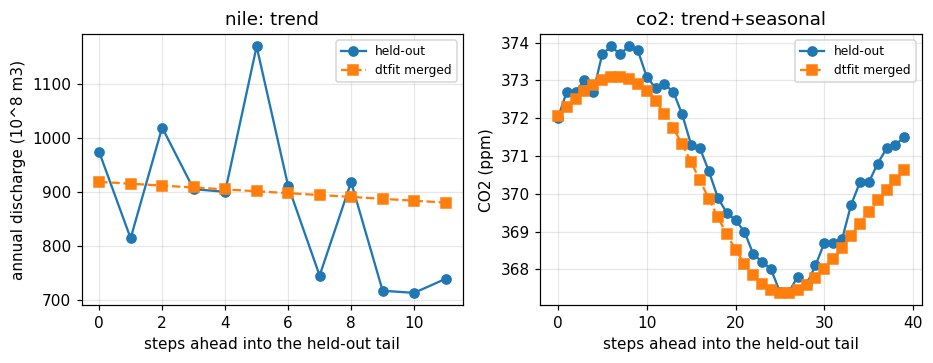

In [6]:
if QUICK:
    print("QUICK: skipping the forecast figure")
else:
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.4))
    units = {"nile": "annual discharge (10^8 m3)", "co2": "CO2 (ppm)"}
    for ax, key in zip(axes, ("nile", "co2")):
        if key not in forecast_ratios.index:
            continue
        rs = [r for r in processes.REAL_SERIES if r.key == key][0]
        y = rs.load()
        h = processes.suite_horizon(y.size)
        train, test = y[:-h], y[-h:]
        model = fit_stochastic(train)
        pred = model.forecast(h)
        t = np.arange(h)
        ax.plot(t, test, "o-", label="held-out")
        ax.plot(t, pred, "s--", label="dtfit merged")
        ax.set_title(f"{key}: {regimes[key]}")
        ax.set_xlabel("steps ahead into the held-out tail")
        ax.set_ylabel(units[key])
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

Every merged ratio in the table is at or below 1.0000; none of the
seven series trails the random walk. CO2 (0.28) and GDP (0.41) are the
two clear wins, both below the 0.5 the claim asked for. Three rows sit at
exactly 1.0000 (T-bill, USD/UAH, LTSF exchange rate): the router calls
all three a plain random walk, so the merged forecaster is literally
`fc_rw`, and 1.0000 is a tie by construction, not a result. GDP's merged and drift columns are identical for the same
reason: the router routes GDP straight to the drift forecaster. Where a
baseline wins outright: ETS on GDP (0.363 against 0.411), AR(1) on the
T-bill (0.845) and on USD/UAH (0.715), ARIMA on sunspots (0.596). Those
are losses on raw forecast accuracy.

In [7]:
if forecast_ratios.empty:
    print("no series loaded, skipping the forecast-skill checks")
else:
    merged = forecast_ratios["dtfit merged"]
    # fails if any series trails the random walk by more than 5 percent
    assert (merged <= 1.05).all(), merged[merged > 1.05]
    for key in ("co2", "gdp"):
        if key in merged.index:
            # fails if CO2 or GDP does not clear the stated forecast-skill
            # bound
            assert merged[key] < 0.5, (key, merged[key])
    print(f"worst merged/RW ratio: {merged.max():.4f}")

worst merged/RW ratio: 1.0000


In [8]:
if len(forecast_ratios) == len(processes.REAL_SERIES):
    notebook.save_table("36_stochastic_real", "real_forecast_skill",
                        forecast_ratios.reset_index())
    print("wrote experiments/results/36_stochastic_real/real_forecast_skill.csv")
else:
    print(f"only {len(forecast_ratios)}/{len(processes.REAL_SERIES)} "
          "series loaded, skipping the CSV export")

wrote experiments/results/36_stochastic_real/real_forecast_skill.csv


## 3. USD/UAH: level versus volatility

The level is a near-random walk; the long memory the literature
attributes to an FX series lives in the volatility, not the level. This
section reads the level's own tie with the random walk (from section 2)
and then compares the Hurst exponent of the absolute log-returns across
both of dtfit's image routes (`hurst_spectral`, `hurst_aggvar`) and the
two classical estimators (R/S, DFA), against the same four estimators
read on the signed log-returns as a control.

In [9]:
if not USD_PATH:
    print("usd_uah_2014_2015.csv missing, skipping this section")
else:
    usd = processes.load_series("usd_uah_2014_2015.csv")
    usd_ratio = forecast_ratios.loc["usd_uah", "dtfit merged"]
    usd_model = fit_stochastic(usd[:-processes.suite_horizon(usd.size)])
    print(f"usd_uah level: regime={gallery.loc['usd_uah', 'detected']} "
          f"forecaster={usd_model.forecaster_name} "
          f"merged/RW={usd_ratio:.4f}")
    log_ret = np.diff(np.log(usd))
    abs_ret = np.abs(log_ret)
    hurst = pd.Series(processes.hurst_comparison(abs_ret), name="H")
    hurst.index.name = "estimator"
    signed_hurst = pd.Series(processes.hurst_comparison(log_ret), name="H")
    signed_hurst.index.name = "estimator"
    print("absolute returns (volatility):")
    print(hurst)
    print("signed returns (control):")
    print(signed_hurst)

usd_uah level: regime=random walk forecaster=random walk merged/RW=1.0000
absolute returns (volatility):
estimator
dtfit spectral    0.730363
dtfit aggvar      0.691823
R/S               0.697396
DFA               0.744960
Name: H, dtype: float64
signed returns (control):
estimator
dtfit spectral    0.534290
dtfit aggvar      0.553631
R/S               0.622464
DFA               0.661896
Name: H, dtype: float64


The router sends the level to the random-walk forecaster itself, so the
merged ratio is 1.0000 by construction and the level is tied, not beaten.
The four Hurst readings of the absolute returns agree with each other
inside a narrow band, all comfortably above 0.5. The signed returns are
not silent either: three of the four estimators also clear 0.55 on
them, at 0.53 to 0.66 against 0.69 to 0.74 on the absolute series, so
the split is a matter of degree, all four estimators read markedly more
memory in the volatility than in the signed series, not an absolute
absence of memory in the returns themselves.

In [10]:
if USD_PATH:
    # fails if the level forecast strays from the random walk by more than 2%
    assert abs(usd_ratio - 1.0) <= 0.02, usd_ratio
    # fails if any Hurst route reads the volatility as short-memory
    assert (hurst > 0.55).all(), hurst
    # fails if the two image routes and the two classical estimators disagree
    assert (hurst.max() - hurst.min()) <= 0.1, hurst
    # fails if any estimator reads the signed returns as more persistent
    # than the volatility they are the sign of
    assert (hurst.values > signed_hurst.reindex(hurst.index).values).all(), (
        hurst, signed_hurst)
    print(f"band: [{hurst.min():.4f}, {hurst.max():.4f}]")

band: [0.6918, 0.7450]


In [11]:
if USD_PATH:
    usd_table = hurst.reset_index().rename(columns={"H": "H_abs_returns"})
    usd_table["H_signed_returns"] = signed_hurst.reindex(hurst.index).values
    notebook.save_table("36_stochastic_real", "usd_uah", usd_table)
    print("wrote experiments/results/36_stochastic_real/usd_uah.csv")
else:
    print("QUICK/missing data: skipping the CSV export")

wrote experiments/results/36_stochastic_real/usd_uah.csv


## 4. The Nile: what the cycle gate did and what closed it

Notebook 23 measures the cycle gate's false-positive rate against record
length; this section carries only the Nile's own numbers. The Nile's
held-out split leaves `n=88` training years (1871-1958), the same length
notebook 23's calibration is read against.
It also reads the Nile's Hurst exponent by the same four estimators
section 3 uses on USD/UAH, which is the memory the record does carry.

In [12]:
nile_full = None
for rs in processes.REAL_SERIES:
    if rs.key == "nile":
        nile_full = rs.load()
if nile_full is None:
    print("nile unavailable (statsmodels missing), skipping this section")
else:
    h_nile = processes.suite_horizon(nile_full.size)
    train = nile_full[:-h_nile]
    n = train.size
    from dtfit.stochastic import as_image
    img = as_image(train)
    seas = img.seasonal(max_harmonics=4)
    strength, period = seas["strength"], seas["period"]
    crit = _fisher_g_crit(n)
    MIN_CYCLES = 2.5
    print(f"n={n} h={h_nile} period={period:.3f}y strength={strength:.4f} "
          f"0.08 floor={'clears' if strength > 0.08 else 'fails'} "
          f"Fisher-g crit={crit:.4f} "
          f"({'clears' if strength > crit else 'falls under'})")
    print(f"the gate admits a period from 4.0y to n/{MIN_CYCLES} = "
          f"{n / MIN_CYCLES:.1f}y at this record length")

n=88 h=12 period=19.668y strength=0.1026 0.08 floor=clears Fisher-g crit=0.1459 (falls under)
the gate admits a period from 4.0y to n/2.5 = 35.2y at this record length


In [13]:
if nile_full is not None:
    t = np.arange(n, dtype=float)
    step_idx = 1899 - 1871

    def aic(rss, k, n):
        return n * np.log(rss / n) + 2 * k

    c_line = np.polyfit(t, train, 1)
    rss_line = float(np.sum((train - np.polyval(c_line, t)) ** 2))
    design_step = np.column_stack([np.ones(n), (t >= step_idx).astype(float)])
    coef_step, *_ = np.linalg.lstsq(design_step, train, rcond=None)
    rss_step = float(np.sum((train - design_step @ coef_step) ** 2))
    aic_line, aic_step = aic(rss_line, 2, n), aic(rss_step, 2, n)
    print(f"line: slope={c_line[0]:.4f}/yr AIC={aic_line:.2f}")
    print(f"step at 1899: shift={coef_step[1]:.2f} AIC={aic_step:.2f} "
          f"(beats the line by {aic_line - aic_step:.2f})")

    img_step = as_image(train - design_step @ coef_step)
    seas_step = img_step.seasonal(max_harmonics=4)
    print(f"spectral peak after removing the line: period={period:.3f}y")
    print(f"spectral peak after removing the step instead: "
          f"period={seas_step['period']:.3f}y strength={seas_step['strength']:.4f}")

line: slope=-3.4910/yr AIC=882.61
step at 1899: shift=-253.38 AIC=853.73 (beats the line by 28.87)
spectral peak after removing the line: period=19.668y
spectral peak after removing the step instead: period=4.205y strength=0.0889


In [14]:
if nile_full is not None:
    nile_hurst = pd.Series(processes.hurst_comparison(train), name="H")
    nile_hurst.index.name = "estimator"
    nile_hurst_full = pd.Series(processes.hurst_comparison(nile_full), name="H")
    nile_hurst_full.index.name = "estimator"
    print(f"Hurst on the {n}-year train split:")
    print(nile_hurst)
    print(f"Hurst on the whole {nile_full.size}-year record:")
    print(nile_hurst_full)

Hurst on the 88-year train split:
estimator
dtfit spectral    0.838538
dtfit aggvar      0.809411
R/S               0.816282
DFA               0.877327
Name: H, dtype: float64
Hurst on the whole 100-year record:
estimator
dtfit spectral    0.866902
dtfit aggvar      0.796446
R/S               0.801714
DFA               0.610086
Name: H, dtype: float64


In [15]:
if nile_full is not None:
    from dtfit.stochastic import gates as stochastic_gates

    def _tag(estimator):
        return estimator.lower().replace(" ", "_").replace("/", "")

    rmse_with, regime_with = processes.forecast_skill(nile_full, h_nile)
    ratio_with = rmse_with["dtfit merged"] / rmse_with["random walk"]

    orig_crit = stochastic_gates._fisher_g_crit
    stochastic_gates._fisher_g_crit = lambda n, alpha=0.05: 0.0
    try:
        rmse_without, regime_without = processes.forecast_skill(nile_full, h_nile)
    finally:
        stochastic_gates._fisher_g_crit = orig_crit
    ratio_without = rmse_without["dtfit merged"] / rmse_without["random walk"]

    nile_structure = pd.DataFrame([
        {"metric": "strength", "value": strength},
        {"metric": "fisher_g_crit", "value": crit},
        {"metric": "aic_line", "value": aic_line},
        {"metric": "aic_step", "value": aic_step},
        {"metric": "aic_diff_line_minus_step", "value": aic_line - aic_step},
        {"metric": "period_after_line", "value": period},
        {"metric": "period_after_step", "value": seas_step["period"]},
        {"metric": "regime_without_test", "value": regime_without},
        {"metric": "ratio_without_test", "value": ratio_without},
        {"metric": "regime_with_test", "value": regime_with},
        {"metric": "ratio_with_test", "value": ratio_with},
    ] + [
        {"metric": f"hurst_train_{_tag(k)}", "value": v}
        for k, v in nile_hurst.items()
    ] + [
        {"metric": f"hurst_full_{_tag(k)}", "value": v}
        for k, v in nile_hurst_full.items()
    ]).set_index("metric")
    display(nile_structure)


,value
metric,
strength,0.102583
fisher_g_crit,0.145871
aic_line,882.608047
aic_step,853.733616
aic_diff_line_minus_step,28.874432
period_after_line,19.668366
period_after_step,4.204537
regime_without_test,trend+cycle
ratio_without_test,1.54354


The 19.7-year "cycle" the effect-size floor alone accepts comes from
fitting a line through the 1899 Aswan Low Dam level shift: a step at that year beats
the pooled line by a wide AIC margin at equal parameter count, and once
the step is removed instead of the line the spectral peak moves to
4.205y at strength=0.0889, inside the 4.0y to 35.2y band this record
length admits and still above the 0.08 effect-size floor.
What closes the gate on either de-trending choice is the Fisher-g
significance test: 0.0889 (step) and 0.1026 (line) both fall under the
crit=0.1459 threshold at this record length, so the stacked guard
rejects both candidates and the forecast ratio drops with it. The
router still calls the Nile "trend", which is the level shift misread
as a slope, not the cycle; that is not what this gate fixes, and is
named again in the limits below.

The memory the record does carry is long-range dependence. On the
88-year train split the four estimators read H=0.8385 (spectral),
0.8094 (aggregated variance), 0.8163 (R/S) and 0.8773 (DFA): all well
above 0.55, inside a 0.07 band, and short of the 0.9 the literature
quotes for the river. On the whole 100-year record the first three hold
at 0.7964 to 0.8669 while DFA drops to 0.6101, so the read-out quoted
here is the train-split one, measured on the same split as every other
number in this section.

In [16]:
if nile_full is not None:
    # fails if the fundamental does not clear the effect-size floor
    assert strength > 0.08, strength
    # fails if the fundamental is not the one the Fisher-g test rejects here
    assert strength < crit, (strength, crit)
    # fails if the step model does not clearly beat the pooled line
    assert (aic_line - aic_step) >= 20.0, (aic_line, aic_step)
    # fails if the gate does not close and the regime is not read as trend
    assert regime_with == "trend", regime_with
    assert ratio_with <= 1.0, ratio_with
    # fails if any estimator reads the train split as short-memory or as
    # reaching the 0.9 the literature quotes for the river
    assert ((nile_hurst > 0.55) & (nile_hurst < 0.9)).all(), nile_hurst
    # fails if the two image routes and the two classical estimators disagree
    assert (nile_hurst.max() - nile_hurst.min()) <= 0.1, nile_hurst
    print(f"without the significance test: regime={regime_without} "
          f"ratio={ratio_without:.4f}; with it: regime={regime_with} "
          f"ratio={ratio_with:.4f}")

without the significance test: regime=trend+cycle ratio=1.5435; with it: regime=trend ratio=0.9150


In [17]:
if nile_full is not None:
    notebook.save_table("36_stochastic_real", "nile_structure", nile_structure)
    print("wrote experiments/results/36_stochastic_real/nile_structure.csv")

wrote experiments/results/36_stochastic_real/nile_structure.csv


In [18]:
if nile_full is not None:
    from dtfit.stochastic.forecast import (fc_drift, fc_rw, fc_trend,
                                           select_forecaster)

    PRE_CYCLICAL_STRENGTH, SEL_MARGIN = 0.12, 1.15
    trend_candidates = [("random walk", fc_rw), ("drift", fc_drift),
                        ("trend", fc_trend)]
    wide = select_forecaster(train, img, trend_candidates,
                             margin=SEL_MARGIN)[0]
    strict = select_forecaster(train, img, trend_candidates,
                               margin=1.0)[0]
    # the smallest margin that admits the winner is its backtest RMSE
    # in units of the random walk's
    lo, hi = 1.0, SEL_MARGIN
    for _ in range(20):
        mid = 0.5 * (lo + hi)
        if select_forecaster(train, img, trend_candidates,
                             margin=mid)[0] == strict:
            lo = mid
        else:
            hi = mid
    print(f"pre_cyclical floor {PRE_CYCLICAL_STRENGTH}: the Nile's "
          f"cycle strength {strength:.4f} stays under it")
    print(f"the router forecasts the Nile with "
          f"{fit_stochastic(train).forecaster_name!r}; the same "
          f"candidates pick {wide} at sel_margin {SEL_MARGIN} and "
          f"{strict} at margin 1.0; the smallest margin that admits "
          f"{wide} is {hi:.4f}")


pre_cyclical floor 0.12: the Nile's cycle strength 0.1026 stays under it
the router forecasts the Nile with 'trend'; the same candidates pick trend at sel_margin 1.15 and random walk at margin 1.0; the smallest margin that admits trend is 1.0116


## 5. Findings and limits

The router reads all seven real series the way the literature does; on
the Nile that rests on the cycle gate's significance test, not on its
effect-size floor. Held-out forecast skill never trails the random walk (worst ratio
1.0000, a tie, not a loss) and clearly beats it where the series has real
deterministic structure (CO2, GDP). USD/UAH shows the textbook FX
pattern cleanly: a random-walk level, long memory in the volatility that
four independent estimators agree on. The Nile's own memory is long-range
dependence rather than a cycle: H=0.81 to 0.88 on the train split by all
four estimators.

Limits, printed and not checked:

- The Nile's spurious trend survives. The router has no test that a
  level shift is a better model than a slope, so `slope=-3.49/yr` is
  still reported as a trend; it costs little at `h=12` because the trend
  forecaster anchors near the current level, and it would cost more at a
  longer horizon or on a series with a larger shift.
- The cycle gate's significance test assumes a white-noise null. On
  red-noise data (an AR(1) around phi=0.5) it still opens far more
  often than on white noise; notebook 23 measures that rate against
  record length, this notebook only names it.
- `pre_cyclical` at a hard-coded 0.12 and `sel_margin` at 1.15
  (`gates.py`) are the same kind of uncalibrated constant as the cycle
  gate's effect-size floor. The Nile's cycle strength of 0.1026 stays under
  0.12, so `pre_cyclical` decided nothing here; `sel_margin` decided
  the forecaster, since the smallest margin that admits the trend
  candidate over the random walk is 1.0116 and the router would pick
  the random walk at a margin of 1.0. The 0.9150 held-out ratio above
  is that trend candidate's. Neither constant is touched here.
- The Nile's Hurst read-out is not stable across the record: adding the
  12 held-out years moves DFA from 0.8773 to 0.6101 while the other
  three estimators stay inside 0.7964 to 0.8669, so the quoted band is
  the train split's and not the river's.
- Each series is one historical record: a single realization, not a
  Monte Carlo draw, so the numbers above describe this record, not a
  distribution over possible ones.
- Five of the seven rows depend on `statsmodels` and two on the
  gitignored CSVs. A run missing either source, or both, drops those
  rows from the gallery and skips the sections that read them; the run
  above had all three, so nothing here shows the degraded path.

In [19]:
print(notebook.provenance(STARTED))

2026-09-21 commit d3e267d dtfit 0.4.0 dtfit-experimental 0.1.0 2.0s
